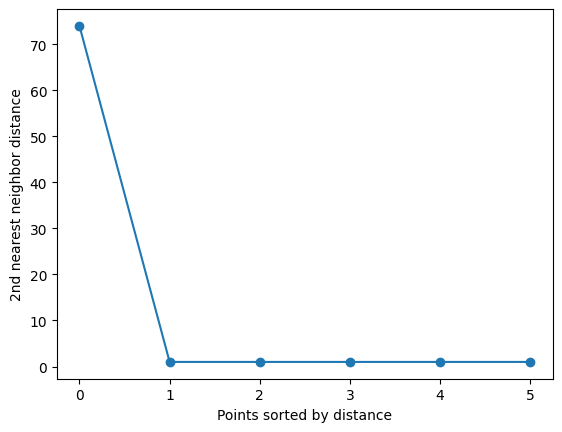

In [1]:
import numpy as np

X = np.array([
    [1, 2], [2, 2], [2, 3], [8, 7], [8, 8], [25, 80]
])


from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

min_samples = 2  # can try 2–4
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort the distances to the 2nd nearest neighbor
distances = np.sort(distances[:, min_samples - 1])[::-1]
plt.plot(distances,marker='o')
plt.ylabel("2nd nearest neighbor distance")
plt.xlabel("Points sorted by distance")
plt.show()


[ 0  0  0  1  1 -1]
0
1
-1
[ 0  0  0  0  0 -1]
0
-1
[ 0  0  0 -1 -1 -1]
0
-1


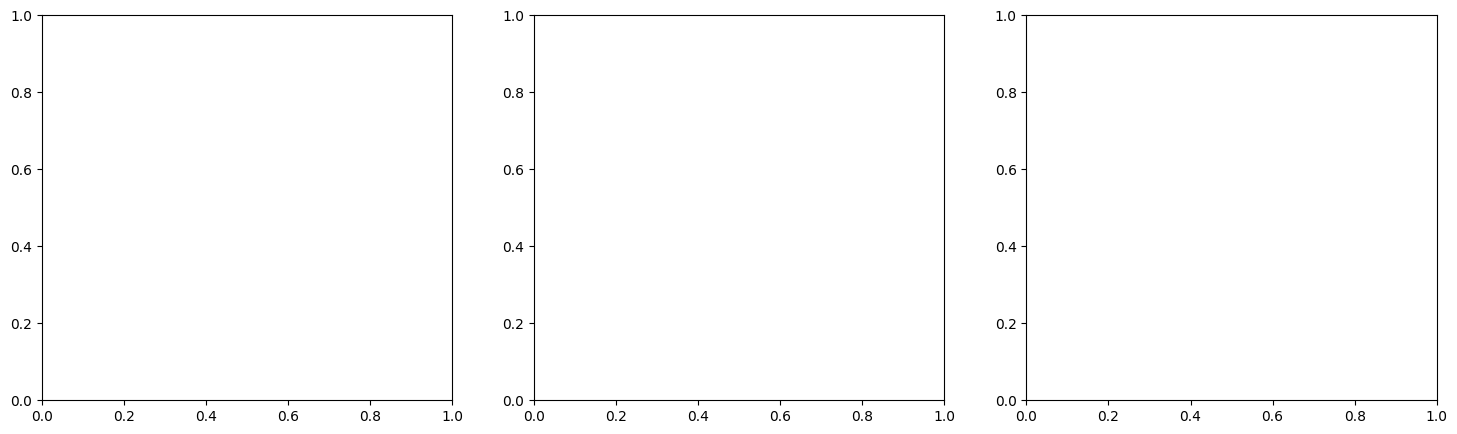

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Step 1: Dataset
X = np.array([
    [1, 2], [2, 2], [2, 3],
    [8, 7], [8, 8],
    [25, 80]
])

# Step 2: Define different trials
trials = [
    {"eps": 1.5, "min_samples": 2, "title": "Trial 1: eps=1.5, min_samples=2"},
    {"eps": 8, "min_samples": 2, "title": "Trial 2: eps=8, min_samples=2"},
    {"eps": 1.5, "min_samples": 3, "title": "Trial 3: eps=1.5, min_samples=3"},
]

# Step 3: Run DBSCAN for each trial and plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, trial in enumerate(trials):
    db = DBSCAN(eps=trial["eps"], min_samples=trial["min_samples"])
    labels = db.fit_predict(X)
    print(labels)
    # Plot
    ax = axes[i]
    for label in set(labels):
        cluster_points = X[labels == label]
        # print(cluster_points)
        print(label)
    #     if label == -1:
    #         ax.scatter(cluster_points[:,0], cluster_points[:,1], c='black', marker='x', s=100, label='Noise')
    #     else:
    #         ax.scatter(cluster_points[:,0], cluster_points[:,1], s=100, label=f'Cluster {label+1}')
    
    # ax.set_title(trial["title"])
    # ax.legend()
    # ax.grid(True)

# plt.show()


In [3]:
import pandas as pd
from sklearn.cluster import DBSCAN

# Step 1: Create a DataFrame
df = pd.DataFrame({
    'x': [1, 2, 2, 8, 8, 25],
    'y': [2, 2, 3, 7, 8, 80]
})

# Step 2: Define DBSCAN trials
trials = [
    {"eps": 1.5, "min_samples": 2, "title": "Trial 1: eps=1.5, min_samples=2"},
    {"eps": 8, "min_samples": 2, "title": "Trial 2: eps=8, min_samples=2"},
    {"eps": 1.5, "min_samples": 3, "title": "Trial 3: eps=1.5, min_samples=3"},
]

# Step 3: Run DBSCAN for each trial and show results
for trial in trials:
    db = DBSCAN(eps=trial["eps"], min_samples=trial["min_samples"])
    df['cluster'] = db.fit_predict(df[['x','y']])
    print(f"\n{trial['title']}")
    print(df)



Trial 1: eps=1.5, min_samples=2
    x   y  cluster
0   1   2        0
1   2   2        0
2   2   3        0
3   8   7        1
4   8   8        1
5  25  80       -1

Trial 2: eps=8, min_samples=2
    x   y  cluster
0   1   2        0
1   2   2        0
2   2   3        0
3   8   7        0
4   8   8        0
5  25  80       -1

Trial 3: eps=1.5, min_samples=3
    x   y  cluster
0   1   2        0
1   2   2        0
2   2   3        0
3   8   7       -1
4   8   8       -1
5  25  80       -1


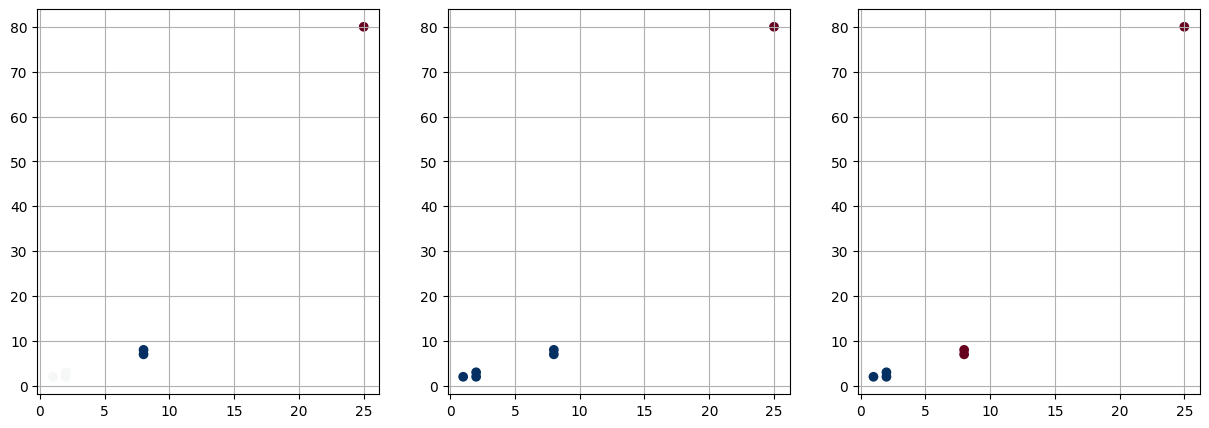

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# Step 1: Create DataFrame
df = pd.DataFrame({
    'x': [1, 2, 2, 8, 8, 25],
    'y': [2, 2, 3, 7, 8, 80]
})

# Step 2: Define DBSCAN trials
trials = [
    {"eps": 1.5, "min_samples": 2},
    {"eps": 8, "min_samples": 2},
    {"eps": 1.5, "min_samples": 3},
]

# Step 3: Loop over trials and plot in one figure
fig, axes = plt.subplots(1, len(trials), figsize=(15,5))

for ax, trial in zip(axes, trials):
    df['cluster'] = DBSCAN(eps=trial['eps'], min_samples=trial['min_samples']).fit_predict(df[['x','y']])
    # automatic coloring using cluster labels
    scatter = ax.scatter(df['x'], df['y'], c=df['cluster'], cmap='RdBu')
    # ax.set_title(f"eps={trial['eps']}, min_samples={trial['min_samples']}")
    ax.grid(True)

plt.show()


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
# Step 1: Create DataFrame
df = pd.DataFrame({
    'x': [1, 2, 2, 8, 8, 25],
    'y': [2, 2, 3, 7, 8, 80]
})

min_samples = 3
model = NearestNeighbors(n_neighbors=min_samples)
model.fit(df).kneighbors(df)

(array([[ 0.        ,  1.        ,  1.41421356],
        [ 0.        ,  1.        ,  1.        ],
        [ 0.        ,  1.        ,  1.41421356],
        [ 0.        ,  1.        ,  7.21110255],
        [ 0.        ,  1.        ,  7.81024968],
        [ 0.        , 73.97972695, 74.95331881]]),
 array([[0, 1, 2],
        [1, 0, 2],
        [2, 1, 0],
        [3, 4, 2],
        [4, 3, 2],
        [5, 4, 3]]))

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('Mall_Customers.csv')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [24]:
# scale = StandardScaler()
# # X[df.drop(['Gender','CustomerID'],axis=1).columns] = scale.fit_transform(df.drop(['Gender','CustomerID'],axis=1))

In [25]:
min_samples = 5
X = df.drop(['Gender','CustomerID'],axis=1)
model = DBSCAN()
X['res'] = model.fit_predict(X)
X
core_point = X[X['res']!=-1]
outliers = X[X['res']==-1]

In [27]:
outliers

,Age,Annual Income (k$),Spending Score (1-100),res
0,19,15,39,-1
1,21,15,81,-1
2,20,16,6,-1
3,23,16,77,-1
4,31,17,40,-1
...,...,...,...,...
195,35,120,79,-1
196,45,126,28,-1
197,32,126,74,-1
198,32,137,18,-1


In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(core_point.Age,core_point.Ann,c=core_point.res,cmap='rainbow')
# core_point = X[X['res']!=-1]
# outliers = X[X['res']==-1]

InvalidIndexError: (slice(None, None, None), 0)

<Figure size 800x600 with 0 Axes>

Number of clusters: 6
Cluster labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(-1)}
[-1  0 -1  0 -1  0 -1 -1 -1  0 -1 -1 -1  0 -1  0  1  0 -1 -1  1  0 -1  0
 -1  0  1 -1  1  0 -1  0 -1  0 -1  0 -1  0  1  0 -1  0  2  3  2 -1  2  3
  3  3  2  3  3  2  2  2  2  2  3  2  2  3  2  2  2  3  2  2  3  3  2  2
  2  2  2  3  2  2  3  2  2  2  2  2  3  2  2  3 -1  2  2  3  2  2  2  3
  2  3  2  3  3  2  2  3  2  3  2  2  2  2  2  3  2  3  3  3  2  2  2  2
  3  2 -1  4 -1  4 -1  4 -1  4  5  4  3  4 -1  4  5  4 -1  4 -1  4 -1  4
 -1  4 -1  4 -1  4  5  4  5  4  5  4 -1  4 -1  4 -1  4 -1  4 -1  4  5  4
 -1 -1  5  4 -1  4 -1  4 -1  4 -1  4 -1  4 -1  4 -1  4 -1 -1 -1  4 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1]


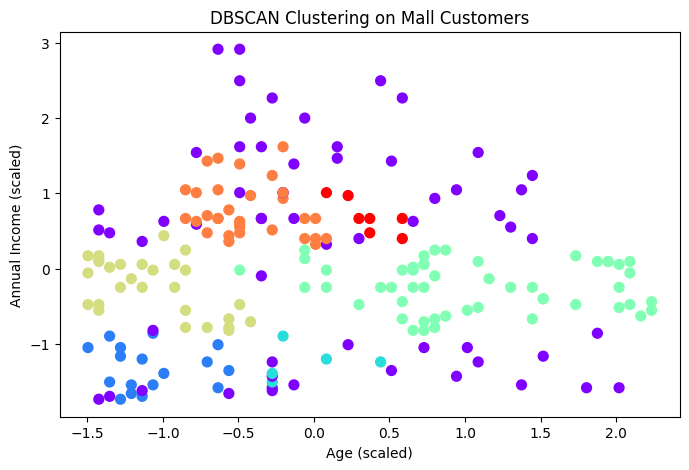

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('Mall_Customers.csv')

# Drop non-numeric / irrelevant columns
X = df.drop(['Gender', 'CustomerID'], axis=1)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN model
db = DBSCAN()  # eps may need tuning
labels = db.fit_predict(X_scaled)

# Number of clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Number of clusters:", n_clusters)
print("Cluster labels:", set(labels))
print(labels)
# Scatter plot (using first two features for visualization)
plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='rainbow', s=50)
plt.xlabel('Age (scaled)')
plt.ylabel('Annual Income (scaled)')
plt.title('DBSCAN Clustering on Mall Customers')
plt.show()


[-1  0 -1  0  0  0 -1  0  0  0  0 -1  0  0 -1  0  0  0  0 -1  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0 -1  1  0  1  0  1 -1  1  0  1  0  1  2  1  0  1  2  1 -1  1  0  1
  2  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  2  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1 -1  1  0  1  0  1
 -1  1 -1  1 -1  1 -1  1]


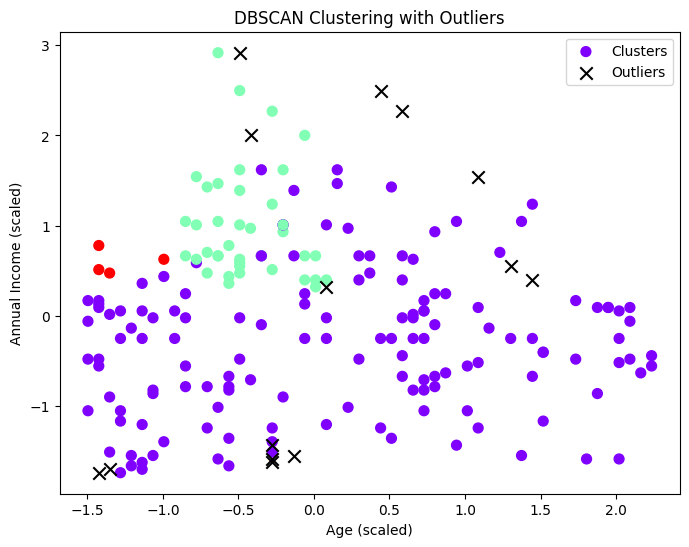

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Mall_Customers.csv')
X = df.drop(['Gender', 'CustomerID'], axis=1)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN model
db = DBSCAN(eps=0.6,min_samples=3)
labels = db.fit_predict(X_scaled)
print(labels)
# Separate points
core_points = X_scaled[labels != -1]
core_labels = labels[labels != -1]

outliers = X_scaled[labels == -1]

# Plot
plt.figure(figsize=(8,6))

# Plot clusters
plt.scatter(core_points[:,0], core_points[:,1], c=core_labels, cmap='rainbow', s=50, label='Clusters')

# Plot outliers
if len(outliers) > 0:
    plt.scatter(outliers[:,0], outliers[:,1], c='black', marker='x', s=80, label='Outliers')

plt.xlabel('Age (scaled)')
plt.ylabel('Annual Income (scaled)')
plt.title('DBSCAN Clustering with Outliers')
plt.legend()
plt.show()


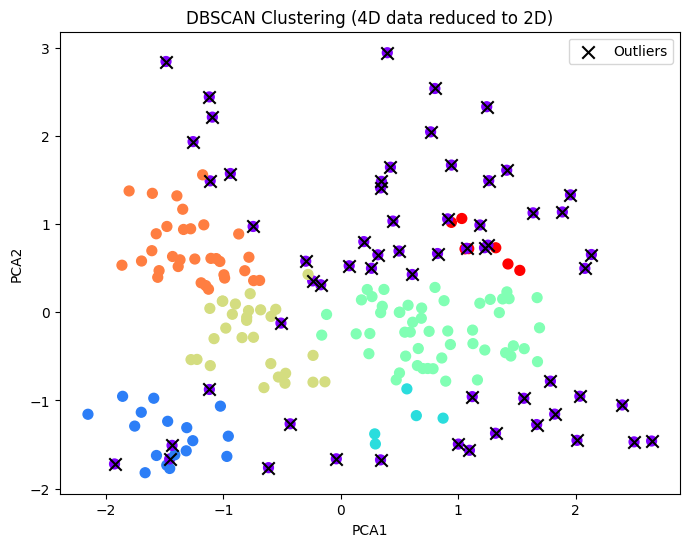

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Mall_Customers.csv')
X = df.drop(['Gender', 'CustomerID'], axis=1)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN model
db = DBSCAN()
labels = db.fit_predict(X_scaled)

# Convert to DataFrame for Seaborn
df_plot = pd.DataFrame(X_scaled, columns=['Age','Annual Income (k$)','Spending Score (1-100)'])
df_plot['Cluster'] = labels.astype(str)  # Convert labels to string for Seaborn hue

# Mark outliers separately
df_plot['Cluster'] = df_plot['Cluster'].replace('-1','Outlier')


from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='rainbow', s=50)

# Mark outliers
plt.scatter(X_pca[labels==-1,0], X_pca[labels==-1,1], c='black', marker='x', s=80, label='Outliers')

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('DBSCAN Clustering (4D data reduced to 2D)')
plt.legend()
plt.show()



In [ ]:
from sklearn.neighbors import NearestNeighbors

model = NearestNeighbors(n_neighbors=4)
model.fit(X_scaled).kneighbors(X_scaled)[1]

array([[  0,   4,  17,  47],
       [  1,   3,  15,   5],
       [  2,   6,  14,   0],
       [  3,   5,  13,  15],
       [  4,  16,  20,   0],
       [  5,   3,  15,  13],
       [  6,  14,  22,  36],
       [  7,  29,   1,  15],
       [  8,  10,  30,  12],
       [  9,  23,  21,  13],
       [ 10,   8,  12,  30],
       [ 11,  19,  25,   7],
       [ 12,  24,  30,   8],
       [ 13,  15,   3,   5],
       [ 14,   6,  36,  22],
       [ 15,  13,   5,   3],
       [ 16,  20,   4,  28],
       [ 17,   5,  31,  21],
       [ 18,  26,  24,  44],
       [ 19,  11,  25,   7],
       [ 20,  16,  28,   4],
       [ 21,  13,  15,   5],
       [ 22,  34,  32,  36],
       [ 23,   9,  37,  25],
       [ 24,  34,  12,  32],
       [ 25,  23,  37,  29],
       [ 26,  28,  42,  44],
       [ 27,  43,  51,  23],
       [ 28,  26,  20,  38],
       [ 29,  35,  41,  33],
       [ 30,   8,  32,  24],
       [ 31,  39,  35,  21],
       [ 32,  24,  34,  30],
       [ 33,  29,  41,  35],
       [ 34,  

[0.06646698 0.06857475 0.07077867 0.07309226 0.07856847 0.07913461
 0.08072515 0.08140767 0.0842805  0.0842805  0.0843573  0.0848044
 0.08765727 0.09040438 0.09191189 0.09191189 0.0919708  0.0926536
 0.0926536  0.09362564 0.09553268 0.10114742 0.10125807 0.10140218
 0.10218263 0.10247819 0.10292455 0.1050468  0.10606083 0.10834771
 0.11036187 0.11075009 0.11250271 0.11303035 0.11490728 0.11492196
 0.11492196 0.1154996  0.1154996  0.1166798  0.11811242 0.12009234
 0.12148923 0.12154073 0.12657324 0.12773339 0.1278383  0.12885396
 0.12907772 0.13246568 0.1344423  0.13521606 0.13629336 0.13663488
 0.13663488 0.13882663 0.13973287 0.13973287 0.14049499 0.14185252
 0.14230169 0.14407634 0.14432515 0.14460268 0.14534102 0.1477982
 0.14989359 0.15063362 0.15234014 0.15234014 0.15731619 0.15778946
 0.15801508 0.16034666 0.16485641 0.17417633 0.17961008 0.17962351
 0.18075747 0.1815036  0.18289664 0.18620057 0.18983495 0.19389865
 0.19632438 0.20080666 0.20898278 0.21012121 0.2103357  0.2138163

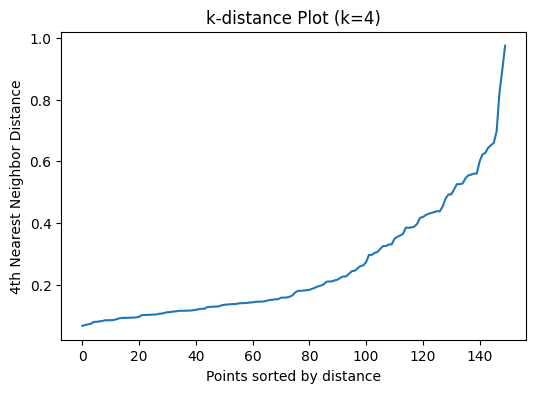

cluster
0    100
1     50
Name: count, dtype: int64


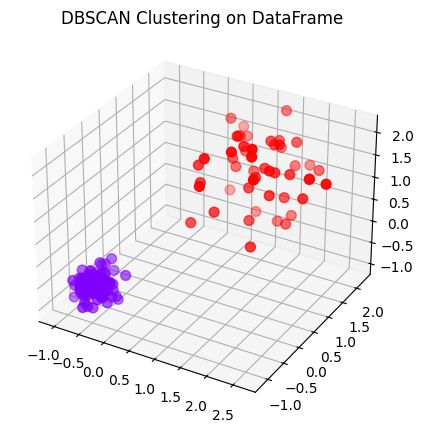

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Step 1: Create dataset (2 clusters of different density)
from sklearn.datasets import make_blobs
X1, _ = make_blobs(n_samples=100, centers=[[0,0,0]], cluster_std=0.3)
X2, _ = make_blobs(n_samples=50, centers=[[3,3,3]], cluster_std=0.8)
X = np.vstack((X1, X2))

# Convert to DataFrame
df = pd.DataFrame(X, columns=['X1','X2','X3'])

# Step 2: Scale features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Step 3: k-distance plot
k = 4  # min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

# Sort distances to k-th neighbor
distances_k = np.sort(distances[:, k-1])
plt.figure(figsize=(6,4))
print(distances_k)
plt.plot(distances_k)
plt.title("k-distance Plot (k=4)")
plt.xlabel("Points sorted by distance")
plt.ylabel("4th Nearest Neighbor Distance")
plt.show()

# Step 4: DBSCAN using eps from elbow (rough estimate)
eps_value = 0.9
db = DBSCAN(eps=eps_value, min_samples=k)
df['cluster'] = db.fit_predict(df_scaled)

# Step 5: Check results
print(df['cluster'].value_counts())

# Optional: 3D visualization
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_scaled['X1'], df_scaled['X2'], df_scaled['X3'], c=df['cluster'], cmap='rainbow', s=50)
ax.set_title("DBSCAN Clustering on DataFrame")
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np

# Step 1: Create sample DataFrame (3D example)
data = {
    'X1': [1, 2, 2.1, 5, 8, 1.5, 3, 3.2, 6, 7.5],
    'X2': [1, 2, 2.1, 5, 8, 1.6, 3, 3.3, 6, 7.2],
    'X3': [0, 1, 1.1, 4, 7, 0.5, 3, 3.1, 5.5, 7]
}
df = pd.DataFrame(data)

# Step 2: Scale features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Step 3: Compute k-distance (min_samples = k)
k = 2
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

# Get distance to k-th nearest neighbor for each point
df['k_distance'] = distances[:, k-1]

# Step 4: Sort k-distance
df_sorted = df.sort_values(by='k_distance').reset_index(drop=True)
k_dist_sorted = df_sorted['k_distance']

# Step 5: Compute first and second differences
diff1 = k_dist_sorted.diff().fillna(0)
diff2 = diff1.diff().fillna(0)
print(diff2)
# Step 6: Find elbow (max second difference)
elbow_index = diff2[diff2 == diff2.max()].index[0]
print(diff2[diff2 == diff2.max()].index[0])
best_eps = k_dist_sorted[elbow_index]

print("Sorted k-distance values:\n", k_dist_sorted.values)
print("\nFirst difference Δ1:\n", diff1.values)
print("\nSecond difference Δ2:\n", diff2.values)
print("\nElbow index:", elbow_index)
print("Best eps (from DataFrame):", best_eps)

# Step 7: Optional - Apply DBSCAN with best eps
db = DBSCAN(eps=best_eps, min_samples=k)
df['cluster'] = db.fit_predict(df_scaled)

print("\nDBSCAN clusters:\n", df[['X1','X2','X3','k_distance','cluster']])

0    0.000000
1    0.000000
2    0.085902
3   -0.085902
4    0.178273
5   -0.127974
6   -0.037173
7   -0.013125
8    0.449042
9   -0.449042
Name: k_distance, dtype: float64
8
Sorted k-distance values:
 [0.07192005 0.07192005 0.15782158 0.15782158 0.33609433 0.38639261
 0.39951762 0.39951762 0.84855929 0.84855929]

First difference Δ1:
 [0.         0.         0.08590153 0.         0.17827275 0.05029828
 0.01312501 0.         0.44904168 0.        ]

Second difference Δ2:
 [ 0.          0.          0.08590153 -0.08590153  0.17827275 -0.12797447
 -0.03717327 -0.01312501  0.44904168 -0.44904168]

Elbow index: 8
Best eps (from DataFrame): 0.8485592934879147

DBSCAN clusters:
     X1   X2   X3  k_distance  cluster
0  1.0  1.0  0.0    0.386393        0
1  2.0  2.0  1.0    0.071920        0
2  2.1  2.1  1.1    0.071920        0
3  5.0  5.0  4.0    0.848559        1
4  8.0  8.0  7.0    0.399518        2
5  1.5  1.6  0.5    0.336094        0
6  3.0  3.0  3.0    0.157822        3
7  3.2  3.3  3.1 